In [3]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Data pipeline

In [ ]:
from data_pipeline import get_dataloaders, plot_dataset_distribution

train_loader, val_loader, test_loader, input_dim, class_mapping = get_dataloaders(
    data_dir="data/01-12",
    is_binary=True,
    batch_size=32
)
print(f"Wymiar wejściowy modelu: {input_dim}")

Loading cached dataset and mapping...
Wymiar wejściowy modelu: 77


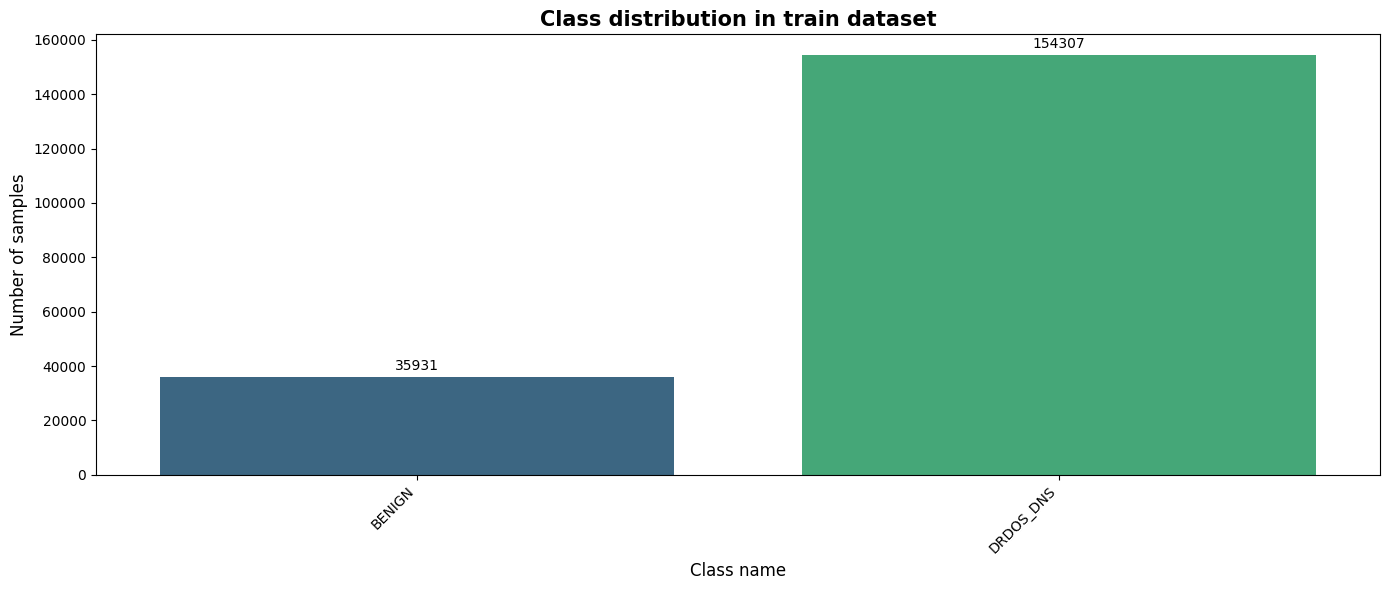

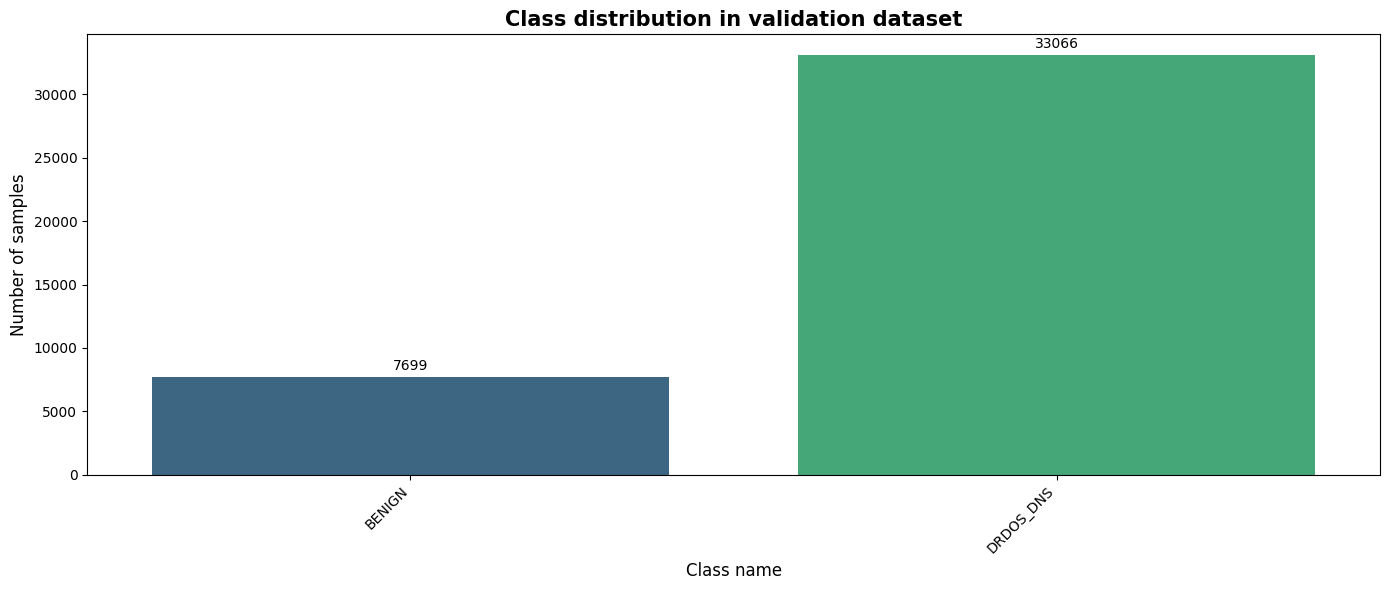

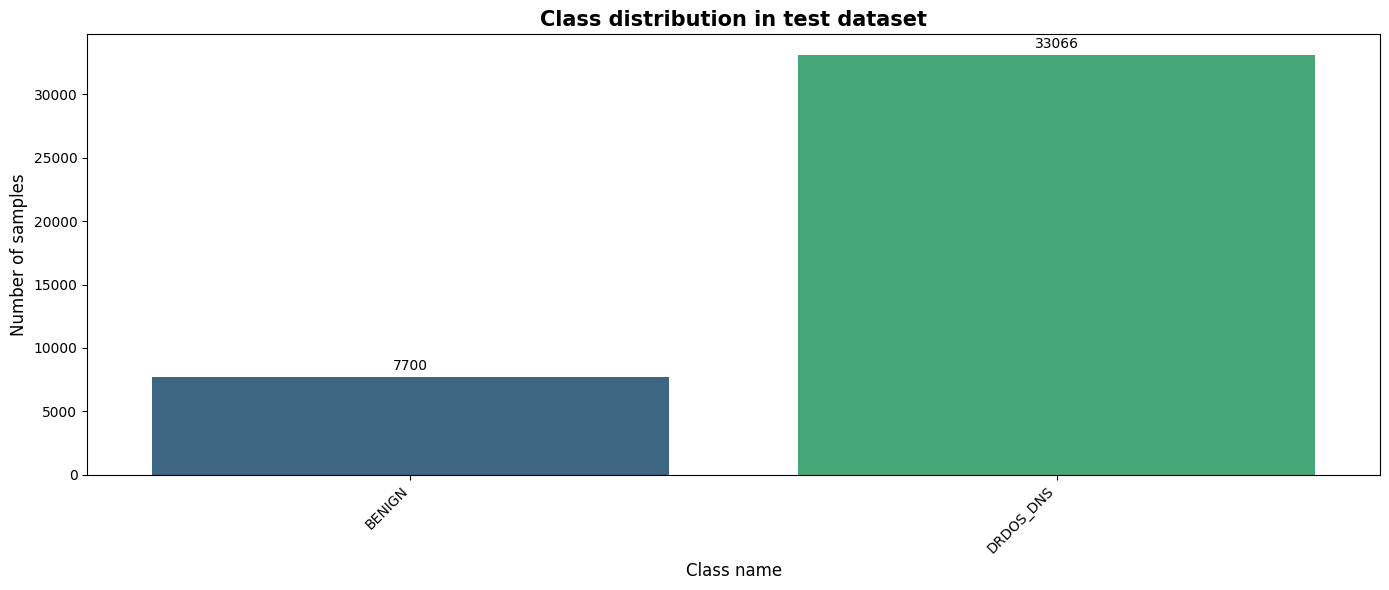

In [6]:
train_dataset, valid_dataset, test_dataset = train_loader.dataset, val_loader.dataset, test_loader.dataset

plot_dataset_distribution(train_dataset.y, class_mapping, dataset_name="train dataset")
plot_dataset_distribution(valid_dataset.y, class_mapping, dataset_name="validation dataset")
plot_dataset_distribution(test_dataset.y, class_mapping, dataset_name="test dataset")

# Modele

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print(f"Dostępność GPU: {torch.cuda.is_available()}")
print(f"Typ GPU: {torch.cuda.get_device_name(0)}")

Dostępność GPU: True
Typ GPU: NVIDIA GeForce RTX 4070 SUPER


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

device(type='cuda')

## Klasy modeli

In [23]:
class DDoSNetEncoder(nn.Module):
    def __init__(self, input_dim):
        super(DDoSNetEncoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=input_dim, hidden_size=64, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=64, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=32, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=16, hidden_size=8, batch_first=True, nonlinearity='relu')

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)
        return x

In [20]:
class DDoSNetDecoder(nn.Module):
    def __init__(self, output_dim):
        super(DDoSNetDecoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=8, hidden_size=8, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=8, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=16, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=32, hidden_size=64, batch_first=True, nonlinearity='relu')

        self.reconstruction_layer = nn.Linear(64, output_dim)

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)

        reconstructed = self.reconstruction_layer(x)
        return reconstructed

In [21]:
class DDoSNetReconstruction(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetReconstruction, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

    def forward(self, x):
        encoded_sequence = self.encoder(x)
        reconstructed_sequence = self.decoder(encoded_sequence)

        return reconstructed_sequence

In [22]:

class DDoSNetClassifier(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetClassifier, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

        self.classifier = nn.Linear(input_dim, 2)

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)

        last_step_reconstructed = reconstructed[:, -1, :]
        logits = self.classifier(last_step_reconstructed)

        return logits

## Trenowanie

In [25]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Funkcje trenujące 

In [26]:
def pretrain_autoencoder(model, train_loader, val_loader, device, epochs=50, lr=0.0001, save_dir="./saved_models"):
    """
    ETAP 1: Unsupervised Pre-training
    Cel: Nauczenie sieci rekonstrukcji ruchu sieciowego (bez etykiet).
    """
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_autoencoder_full.pth")
    best_encoder_path = os.path.join(save_dir, "best_encoder_only.pth")


    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    train_losses = [None]*epochs
    val_losses = [None]*epochs

    model.to(device)

    print("--- ROZPOCZĘCIE ETAPU 1: Nienadzorowany Pre-training ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for inputs, _ in tqdm(train_loader):
            inputs = inputs.to(device)
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            optimizer.zero_grad()

            reconstructed = model(inputs)

            loss = criterion(reconstructed, inputs)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses[epoch] = avg_train_loss

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(device)
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                reconstructed = model(inputs)
                loss = criterion(reconstructed, inputs)

                val_loss += loss.item() * inputs.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses[epoch] = avg_val_loss

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            torch.save(model.encoder.state_dict(), best_encoder_path)

    print(f"\nTrening zakończony. Najlepszy błąd walidacji: {best_val_loss:.6f}")
    print(f"Pełny model zapisano w: {best_model_path}")
    print(f"Sam koder zapisano w: {best_encoder_path}")



    print("--- ZAKOŃCZONO ETAP 1 ---\n")
    return model, (train_losses, val_losses)

In [27]:
def finetune_classifier(model, train_loader, val_loader, device, epochs=50, lr=0.0001):
    """
    ETAP 2: Supervised Fine-tuning
    Cel: Klasyfikacja ruchu (Normalny vs Atak) z wykorzystaniem etykiet
         i optymalizacja wag całej sieci.
    """
    print("--- ROZPOCZĘCIE ETAPU 2: Nadzorowany Fine-tuning ---")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    train_losses = [None]*epochs
    val_losses = [None]*epochs
    train_acc = [None]*epochs
    val_acc = [None]*epochs

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).long()
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)


            optimizer.zero_grad()

            logits = model(inputs)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = train_correct / total
        train_losses[epoch] = epoch_train_loss
        train_acc[epoch] = epoch_train_acc

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                logits = model(inputs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses[epoch] = epoch_val_loss
        val_acc[epoch] = epoch_val_acc

        print(f'Fine-tuning Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    print("\nTrening zakończony. Ładowanie najlepszego modelu z Etapu 2...")
    model.load_state_dict(best_model_weights)
    return model, (train_losses, val_losses), (train_acc, val_acc)


In [28]:
def plot_learning_curves(train_losses, val_losses):
    """
    Rysuje wykres błędu treningowego i walidacyjnego.
    train_losses: lista wartości avg_train_loss z kolejnych epok
    val_losses: lista wartości avg_val_loss z kolejnych epok
    """
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, 'b-', label='Trening (Train Loss)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Walidacja (Val Loss)', linewidth=2, marker='s', markersize=4)

    plt.title('Krzywe uczenia modelu', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Strata (Loss - MSE)', fontsize=12)

    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(epochs)

    plt.tight_layout()
    plt.show()


In [40]:
def plot_accuracy_curves(train_accs, val_accs):
    """
    Rysuje wykres dokładności treningowej i walidacyjnej.
    train_accs: lista wartości avg_train_acc z kolejnych epok
    val_accs: lista wartości avg_val_acc z kolejnych epok
    """
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_accs, 'g-', label='Trening (Train Acc)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_accs, 'darkorange', label='Walidacja (Val Acc)', linewidth=2, marker='s', markersize=4)

    plt.title('Krzywe dokładności modelu (Accuracy)', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Dokładność (Accuracy)', fontsize=12)

    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(epochs)

    # plt.ylim(0.0, 1.05)

    plt.tight_layout()
    plt.show()

In [30]:
def evaluate_and_plot_confusion_matrix(model, test_loader, device):
    """
    Ewaluuje model na zbiorze testowym, oblicza metryki i rysuje macierz pomyłek.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            inputs = inputs.unsqueeze(1)

            logits = model(inputs)

            _, predicted = torch.max(logits.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nOstateczna dokładność (Accuracy) na zbiorze testowym: {acc:.4f}")

    print("\nRaport Klasyfikacji:")
    print(classification_report(all_labels, all_preds, target_names=["Normalny (0)", "Atak (1)"]))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Przewidziano: Normalny", "Przewidziano: Atak"],
                yticklabels=["Faktycznie: Normalny", "Faktycznie: Atak"])

    plt.title('Macierz Pomyłek (Confusion Matrix) - Zbiór Testowy', fontsize=14, pad=15)
    plt.ylabel('Prawdziwe etykiety', fontsize=12)
    plt.xlabel('Etykiety przewidziane przez model', fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

def evaluate_and_plot_roc(model, test_loader, device):
    """
    Ewaluuje model na zbiorze testowym, oblicza prawdopodobieństwa
    i rysuje krzywą ROC wraz z polem pod krzywą (AUC).
    """
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()

            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            logits = model(inputs)

            probabilities = F.softmax(logits, dim=1)

            attack_probs = probabilities[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(attack_probs.cpu().numpy())

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))

    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'DDoSNet (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy wybór (AUC = 0.5000)')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Odsetek fałszywych alarmów (False Positive Rate)', fontsize=12)
    plt.ylabel('Odsetek wykrytych ataków (True Positive Rate)', fontsize=12)
    plt.title('Krzywa ROC - Detekcja Ataków DDoS', fontsize=14, pad=15)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return fpr, tpr, roc_auc

### Trenowanie rekonstrukcji

In [32]:
model_reconstruction = DDoSNetReconstruction(input_dim=input_dim)

In [33]:
pretrained_model, losses1 = pretrain_autoencoder(model_reconstruction, train_loader, val_loader, device,epochs=50, lr=0.0001)

--- ROZPOCZĘCIE ETAPU 1: Nienadzorowany Pre-training ---


100%|██████████| 5945/5945 [00:24<00:00, 245.11it/s]


Epoch 01/50 | Train Loss: 0.007530 | Val Loss: 0.002435


100%|██████████| 5945/5945 [00:21<00:00, 278.48it/s]


Epoch 02/50 | Train Loss: 0.001390 | Val Loss: 0.000880


...

Epoch 48/50 | Train Loss: 0.000100 | Val Loss: 0.000096


100%|██████████| 5945/5945 [00:24<00:00, 242.33it/s]


Epoch 49/50 | Train Loss: 0.000099 | Val Loss: 0.000096


100%|██████████| 5945/5945 [00:23<00:00, 256.68it/s]


Epoch 50/50 | Train Loss: 0.000098 | Val Loss: 0.000093

Trening zakończony. Najlepszy błąd walidacji: 0.000093
Pełny model zapisano w: ./saved_models\best_autoencoder_full.pth
Sam koder zapisano w: ./saved_models\best_encoder_only.pth
--- ZAKOŃCZONO ETAP 1 ---



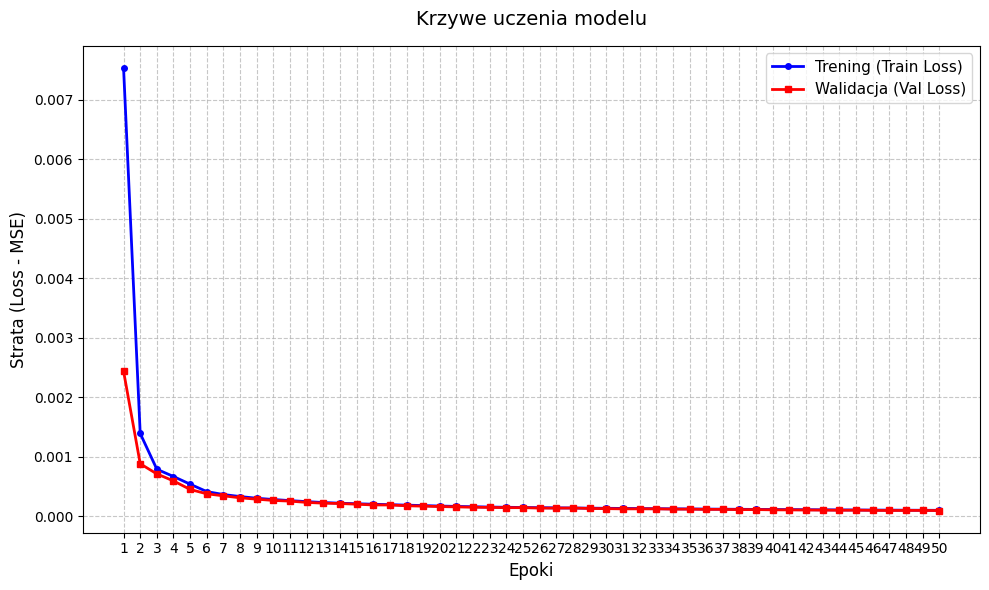

In [34]:
plot_learning_curves(*losses1)

### Trenowanie klasyfikacji

In [35]:
loaded_reconstruction_model = DDoSNetReconstruction(input_dim=input_dim)
saved_model_path = "./saved_models/best_autoencoder_full.pth"

loaded_reconstruction_model.load_state_dict(
    torch.load(saved_model_path, map_location=device)
)

<All keys matched successfully>

In [36]:
pretrained_encoder = loaded_reconstruction_model.encoder
pretrained_decoder = loaded_reconstruction_model.decoder

classifier_model = DDoSNetClassifier(
    input_dim=input_dim,
    encoder=pretrained_encoder,
    decoder=pretrained_decoder
)

In [37]:
final_model, losses2, accuraties = finetune_classifier(classifier_model, train_loader, val_loader, device, epochs=50, lr=0.0001)

--- ROZPOCZĘCIE ETAPU 2: Nadzorowany Fine-tuning ---


100%|██████████| 5945/5945 [00:25<00:00, 230.45it/s]


Fine-tuning Epoch 1/50 | Train Loss: 0.0381 Acc: 0.9881 | Val Loss: 0.0166 Acc: 0.9959


100%|██████████| 5945/5945 [00:25<00:00, 234.01it/s]


Fine-tuning Epoch 2/50 | Train Loss: 0.0149 Acc: 0.9966 | Val Loss: 0.0143 Acc: 0.9963


...

Fine-tuning Epoch 48/50 | Train Loss: 0.0052 Acc: 0.9985 | Val Loss: 0.0071 Acc: 0.9980


100%|██████████| 5945/5945 [00:26<00:00, 226.83it/s]


Fine-tuning Epoch 49/50 | Train Loss: 0.0049 Acc: 0.9986 | Val Loss: 0.0062 Acc: 0.9985


100%|██████████| 5945/5945 [00:23<00:00, 248.01it/s]


Fine-tuning Epoch 50/50 | Train Loss: 0.0049 Acc: 0.9986 | Val Loss: 0.0089 Acc: 0.9975

Trening zakończony. Ładowanie najlepszego modelu z Etapu 2...


In [38]:
torch.save(final_model.state_dict(), os.path.join("./saved_models", "best_classifier.pth"))

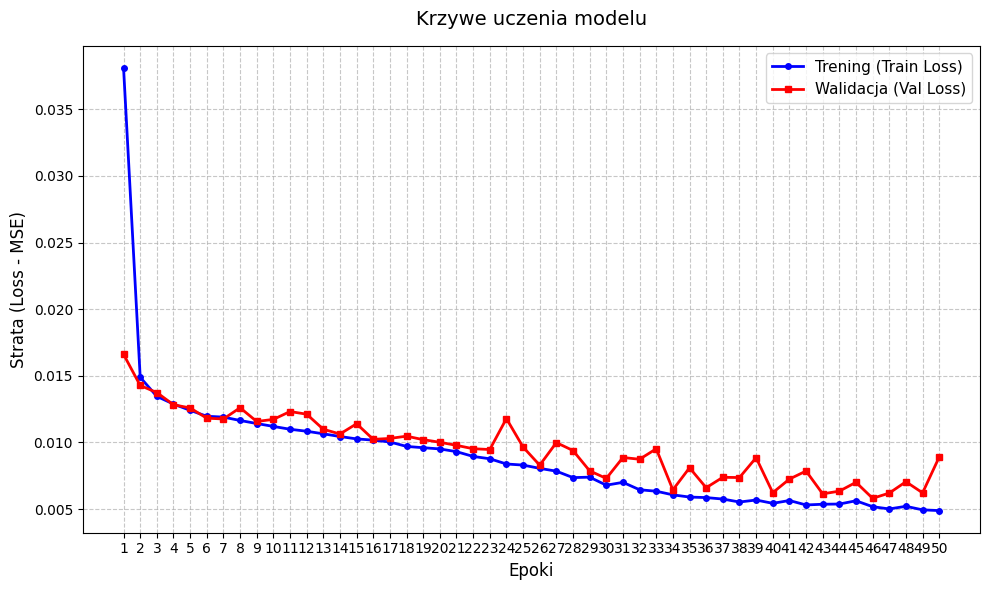

In [39]:
plot_learning_curves(*losses2)

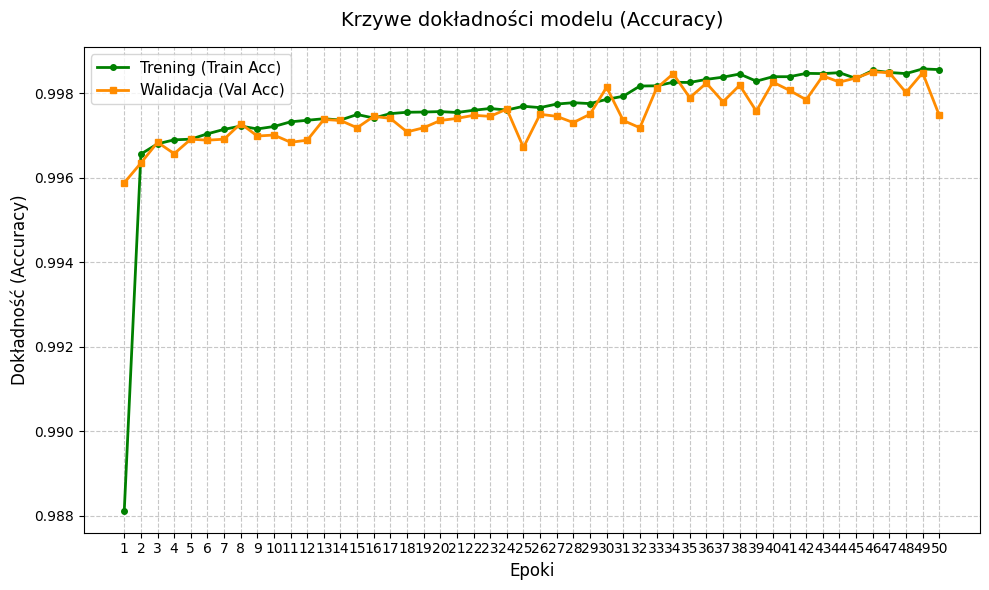

In [41]:
plot_accuracy_curves(*accuraties)


Ostateczna dokładność (Accuracy) na zbiorze testowym: 0.9984

Raport Klasyfikacji:
              precision    recall  f1-score   support

Normalny (0)       1.00      1.00      1.00      7700
    Atak (1)       1.00      1.00      1.00     33066

    accuracy                           1.00     40766
   macro avg       1.00      1.00      1.00     40766
weighted avg       1.00      1.00      1.00     40766



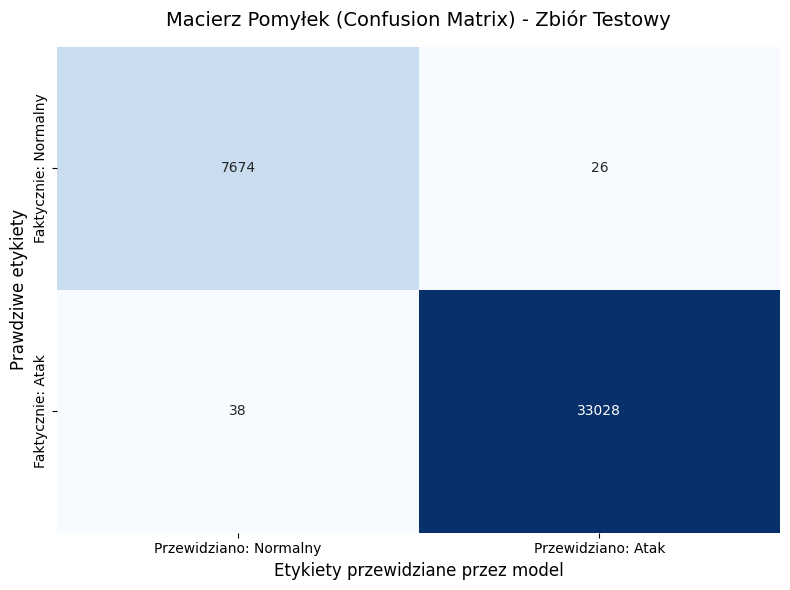

In [42]:
evaluate_and_plot_confusion_matrix(final_model, test_loader, device)

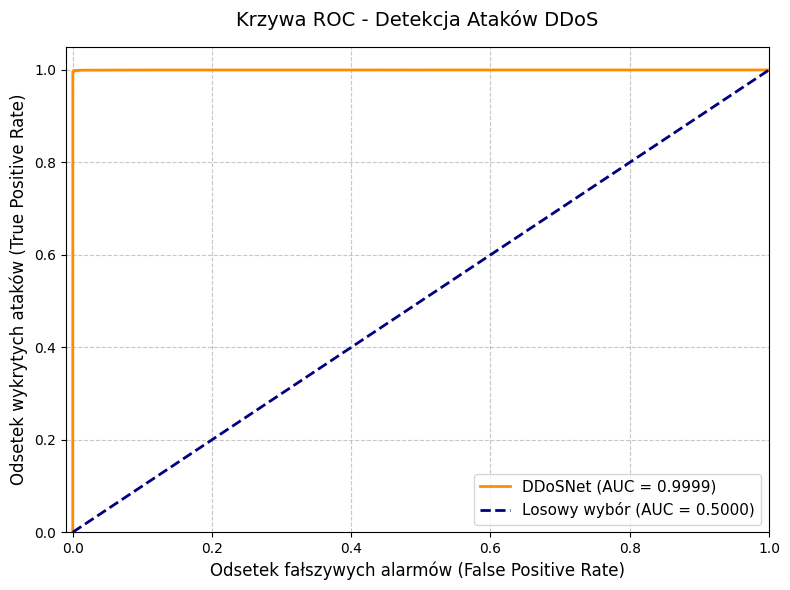

(array([0.        , 0.        , 0.        , ..., 0.98571429, 0.98597403,
        1.        ], shape=(2106,)),
 array([0.        , 0.30826226, 0.38069316, ..., 1.        , 1.        ,
        1.        ], shape=(2106,)),
 0.9999372467186839)

In [44]:
evaluate_and_plot_roc(final_model, test_loader, device)